# K-Moda MMM — Fase 3: Feature Engineering

**Objetivo:** Transformar las inversiones publicitarias brutas en variables con memoria temporal (lag + adstock) listas para el modelo de regresión. Añadir variables exógenas del calendario. Exportar `df_model.parquet`.

**Inputs:** `data/df_ventas_clean.parquet` · `data/df_inversion_clean.parquet`

**Output:** `data/df_model.parquet` — 262 semanas × ~20 features (split TRAIN/TEST explícito)

---
**Transformaciones aplicadas:**
1. **Lag:** `X'_{t,m} = X_{t-L_m, m}` — desplaza la inversión el número de semanas que tarda en impactar en ventas
2. **Adstock:** `A_{t,m} = X'_{t,m} + α_m · A_{t-1,m}` — captura el efecto residual de campañas pasadas (carryover)
3. **Variables exógenas:** flags de eventos comerciales + variables continuas del calendario

## 0. Configuración e Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy import stats

ROOT     = Path('.')
DATA_OUT = ROOT / 'data'
IMG_DIR  = ROOT / 'img'
IMG_DIR.mkdir(exist_ok=True)

KM = {
    'gold': '#C9A84C', 'gold_light': '#E8D5A3', 'charcoal': '#2C2C2C',
    'warm_gray': '#6B6560', 'off_white': '#F7F5F0', 'white': '#FFFFFF',
    'paid_search': '#1A6B8A', 'social_paid': '#E07B39', 'video': '#8B5E9E',
    'display': '#3A9E6F', 'email_crm': '#D4A843', 'radio': '#C0504D',
    'exterior': '#4F7CAC', 'prensa': '#7A7A52',
    'positive': '#2E7D52', 'neutral': '#C9A84C', 'negative': '#B33A3A',
}
CANAL_COLOR = {
    'Paid Search': KM['paid_search'], 'Social Paid': KM['social_paid'],
    'Video Online': KM['video'],      'Display':     KM['display'],
    'Email CRM':   KM['email_crm'],   'Radio Local': KM['radio'],
    'Exterior':    KM['exterior'],    'Prensa':      KM['prensa'],
}
plt.rcParams.update({
    'figure.facecolor': KM['off_white'], 'axes.facecolor': KM['off_white'],
    'axes.edgecolor': KM['warm_gray'],   'axes.labelcolor': KM['charcoal'],
    'xtick.color': KM['charcoal'],       'ytick.color': KM['charcoal'],
    'text.color': KM['charcoal'],        'grid.color': KM['gold_light'],
    'grid.alpha': 0.5, 'axes.grid': True, 'font.family': 'sans-serif',
    'font.size': 11,
})

def save_fig(name, fig=None):
    f = fig or plt.gcf()
    p = IMG_DIR / f'{name}.png'
    f.savefig(p, dpi=150, bbox_inches='tight', facecolor=f.get_facecolor())
    print(f'  Guardado: {p}')

print('Config cargada.')

Config cargada.


## 1. Carga de artefactos Fase 1

In [2]:
df_v = pd.read_parquet(DATA_OUT / 'df_ventas_clean.parquet')
df_i = pd.read_parquet(DATA_OUT / 'df_inversion_clean.parquet')

CANALES = [c for c in df_i.columns if c not in ['semana_inicio','anio','anio_iso','semana_iso']]

print(f'df_ventas_clean:    {df_v.shape}  |  semanas: {len(df_v)}')
print(f'df_inversion_clean: {df_i.shape}  |  canales: {CANALES}')
print(f'Rango: {df_v.semana_inicio.min().date()} → {df_v.semana_inicio.max().date()}')

df_ventas_clean:    (262, 20)  |  semanas: 262
df_inversion_clean: (262, 12)  |  canales: ['Display', 'Email CRM', 'Exterior', 'Paid Search', 'Prensa', 'Radio Local', 'Social Paid', 'Video Online']
Rango: 2019-12-30 → 2024-12-30


## 2. Parámetros Lag y Alpha — Justificación por canal

Los parámetros se fijan combinando dos fuentes:
- **Evidencia empírica:** cross-correlación máxima de Pearson calculada en la Fase 2
- **Naturaleza del canal:** los canales de *performance* (respuesta inmediata) tienen lag bajo y alpha bajo; los canales de *branding* (construcción de marca) tienen lag mayor y alpha mayor

| Canal | Lag EDA | Lag modelo | Alpha | Justificación |
|---|---|---|---|---|
| Paid Search | 0 | 0 | 0.2 | Performance directo; respuesta en < 1 semana; decaimiento rápido |
| Email CRM | 0 | 0 | 0.1 | Acción inmediata post-apertura; sin carryover relevante |
| Social Paid | 0 | 1 | 0.3 | Descubrimiento → consideración → compra: 1 semana típica |
| Display | 2 | 1 | 0.3 | Banner awareness; efecto retardado leve; decaimiento moderado |
| Prensa | 2 | 2 | 0.4 | Medio offline lento; lectores procesan al cabo de días |
| Video Online | 4 | 2 | 0.5 | Branding; build-up progresivo; carryover medio |
| Radio Local | 4 | 2 | 0.6 | Offline branding; repetición de mensaje; carryover alto |
| Exterior | 4 | 2 | 0.7 | Mayor lag y carryover: exposición pasiva acumulada |

> **Nota:** donde el lag empírico es 4, usamos 2 en el modelo para evitar perder demasiadas semanas al inicio del periodo. La sensibilidad a esta elección se analiza en la Sección 4.

In [3]:
# Parámetros confirmados: lag (semanas) y alpha (tasa de decaimiento adstock)
PARAMS = {
    'Paid Search':  {'lag': 0, 'alpha': 0.20},
    'Email CRM':    {'lag': 0, 'alpha': 0.10},
    'Social Paid':  {'lag': 1, 'alpha': 0.30},
    'Display':      {'lag': 1, 'alpha': 0.30},
    'Prensa':       {'lag': 2, 'alpha': 0.40},
    'Video Online': {'lag': 2, 'alpha': 0.50},
    'Radio Local':  {'lag': 2, 'alpha': 0.60},
    'Exterior':     {'lag': 2, 'alpha': 0.70},
}

print('Parámetros Lag/Alpha por canal:')
print(f'{"Canal":15s}  {"Lag":>5s}  {"Alpha":>6s}  {"Tipo"}')
print('-' * 50)
for canal, p in PARAMS.items():
    tipo = 'Performance' if p['alpha'] <= 0.3 else ('Branding' if p['alpha'] >= 0.5 else 'Mixto')
    print(f'{canal:15s}  {p["lag"]:>5d}  {p["alpha"]:>6.2f}  {tipo}')

Parámetros Lag/Alpha por canal:
Canal              Lag   Alpha  Tipo
--------------------------------------------------
Paid Search          0    0.20  Performance
Email CRM            0    0.10  Performance
Social Paid          1    0.30  Performance
Display              1    0.30  Performance
Prensa               2    0.40  Mixto
Video Online         2    0.50  Branding
Radio Local          2    0.60  Branding
Exterior             2    0.70  Branding


## 3. Funciones de transformación: Lag y Adstock

In [4]:
def apply_lag(series: pd.Series, lag: int) -> pd.Series:
    """Desplaza la serie `lag` posiciones hacia adelante (la inversión de semana t-lag afecta a t)."""
    return series.shift(lag)


def apply_adstock(series: pd.Series, alpha: float) -> pd.Series:
    """Adstock recursivo: A_t = X_t + alpha * A_{t-1}. Normalizado para preservar la escala original."""
    result = np.zeros(len(series))
    vals = series.fillna(0).values
    for t in range(len(vals)):
        result[t] = vals[t] + alpha * (result[t-1] if t > 0 else 0.0)
    # Normalización: divide por (1 + alpha + alpha^2 + ...) = 1/(1-alpha) para alpha < 1
    # Esto mantiene la integral de la curva igual a la inversión original
    result = result * (1 - alpha)
    return pd.Series(result, index=series.index, name=series.name)


def lag_adstock(series: pd.Series, lag: int, alpha: float) -> pd.Series:
    """Pipeline completo: lag → adstock."""
    return apply_adstock(apply_lag(series, lag), alpha)


print('Funciones lag_adstock definidas.')

# Verificación rápida: impulso unitario en t=5
test = pd.Series(np.zeros(20))
test.iloc[5] = 1000
test_ads = apply_adstock(test, alpha=0.6)
print(f'Verificacion adstock (alpha=0.6, impulso en t=5):')
print(f'  Suma original: {test.sum():.0f}  |  Suma adstock: {test_ads.sum():.1f}  (conservacion de escala)')
print(f'  Valores t=5..10: {test_ads.iloc[5:11].round(1).tolist()}')

Funciones lag_adstock definidas.
Verificacion adstock (alpha=0.6, impulso en t=5):
  Suma original: 1000  |  Suma adstock: 999.5  (conservacion de escala)
  Valores t=5..10: [400.0, 240.0, 144.0, 86.4, 51.8, 31.1]


## 4. Visualización del efecto Adstock por canal

Simulación de respuesta a un impulso unitario para visualizar el decaimiento teórico de cada canal.

  Guardado: img\03a_adstock_impulso.png


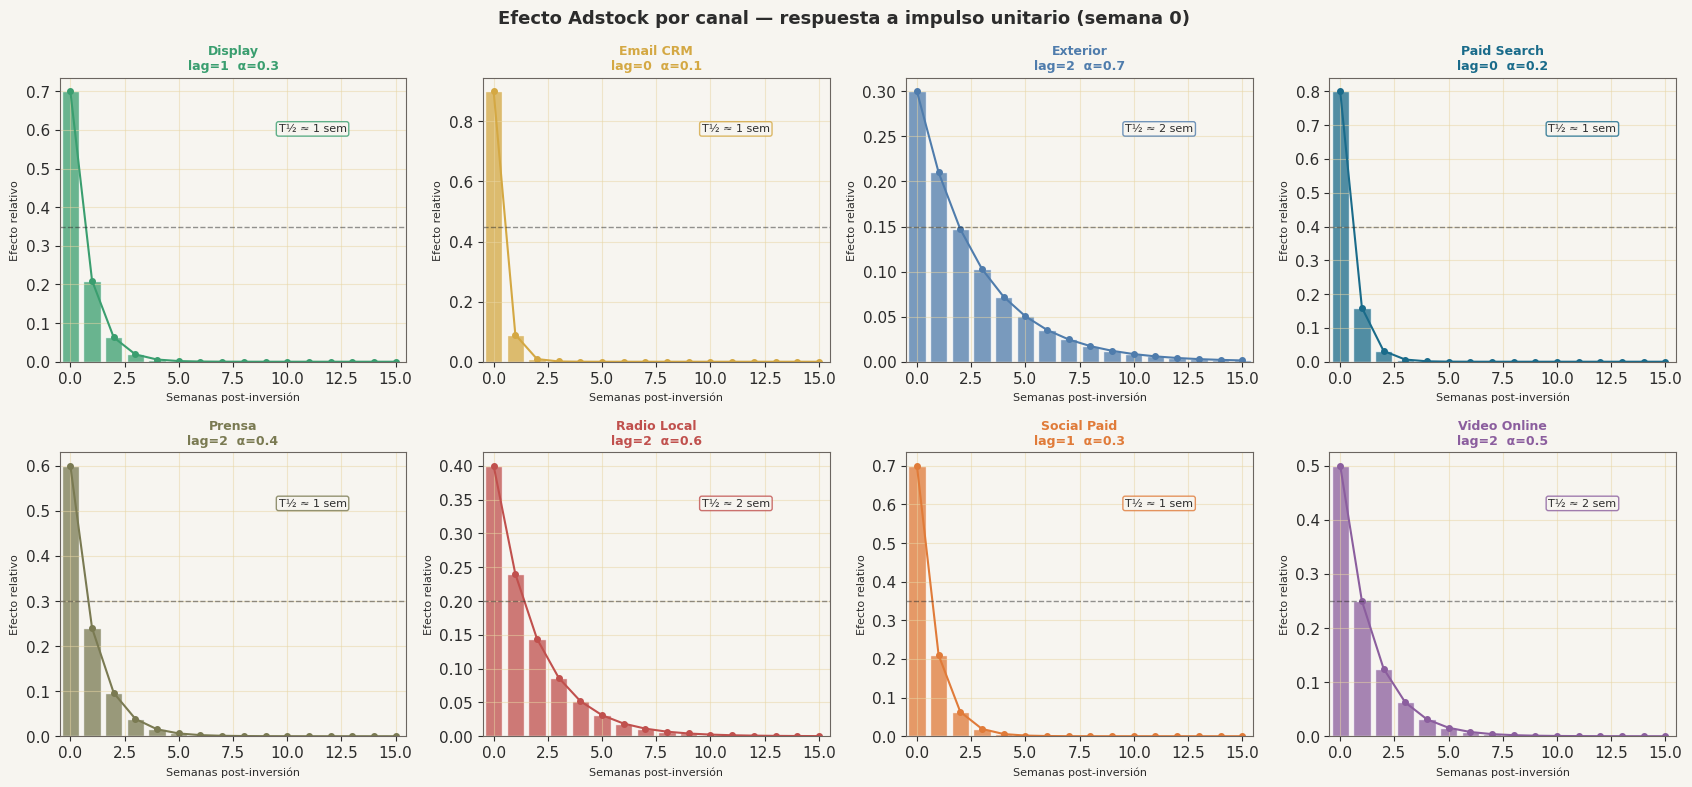

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(17, 8))
fig.suptitle('Efecto Adstock por canal — respuesta a impulso unitario (semana 0)',
             fontsize=13, fontweight='bold', color=KM['charcoal'])

N = 16  # semanas de simulación
impulso = pd.Series(np.zeros(N))
impulso.iloc[0] = 1.0

for ax, canal in zip(axes.flatten(), CANALES):
    p = PARAMS[canal]
    respuesta = apply_adstock(impulso, p['alpha'])
    # Media vida: semana donde el efecto cae al 50%
    half_life = None
    for i, v in enumerate(respuesta):
        if i > 0 and v < respuesta.iloc[0] * 0.5:
            half_life = i
            break

    color = CANAL_COLOR.get(canal, KM['warm_gray'])
    ax.bar(range(N), respuesta.values, color=color, alpha=0.75, edgecolor='white', width=0.8)
    ax.plot(range(N), respuesta.values, color=color, lw=1.5, marker='o', ms=4)
    ax.axhline(respuesta.iloc[0] * 0.5, color=KM['charcoal'], lw=1, ls='--', alpha=0.5)
    ax.set_title(f'{canal}\nlag={p["lag"]}  α={p["alpha"]}',
                 fontsize=9, color=color, fontweight='bold')
    ax.set_xlabel('Semanas post-inversión', fontsize=8)
    ax.set_ylabel('Efecto relativo', fontsize=8)
    ax.set_xlim(-0.5, N - 0.5)
    hl_txt = f'T½ ≈ {half_life} sem' if half_life else 'T½ > 15 sem'
    ax.text(N * 0.6, respuesta.iloc[0] * 0.85, hl_txt,
            fontsize=8, color=KM['charcoal'],
            bbox=dict(boxstyle='round,pad=0.2', fc=KM['off_white'], ec=color, alpha=0.8))

plt.tight_layout()
save_fig('03a_adstock_impulso')
plt.show()

## 5. Aplicación de Lag + Adstock a la serie real

In [6]:
# Ordenar por fecha (garantía)
df_inv = df_i.sort_values('semana_inicio').reset_index(drop=True)

# Construir columnas adstock para cada canal
adstock_cols = {}
for canal in CANALES:
    p = PARAMS[canal]
    col_name = f'adstock_{canal.lower().replace(" ", "_")}'
    adstock_cols[col_name] = lag_adstock(df_inv[canal], lag=p['lag'], alpha=p['alpha'])

df_adstock = pd.DataFrame(adstock_cols, index=df_inv.index)
df_adstock['semana_inicio'] = df_inv['semana_inicio'].values

# Verificar conservación de escala (suma total debe ser ~igual)
print('VERIFICACIÓN DE ESCALA — suma inversión original vs adstock:')
print(f'{"Canal":15s}  {"Original (M€)":>14s}  {"Adstock (M€)":>13s}  {"Ratio":>6s}')
print('-' * 55)
for canal in CANALES:
    col_name = f'adstock_{canal.lower().replace(" ", "_")}'
    orig = df_inv[canal].sum() / 1e6
    ads  = df_adstock[col_name].sum() / 1e6
    print(f'{canal:15s}  {orig:>14.3f}  {ads:>13.3f}  {ads/orig:>6.3f}')

ADSTOCK_COLS = list(adstock_cols.keys())
print(f'\nColumnas adstock generadas: {len(ADSTOCK_COLS)}')

VERIFICACIÓN DE ESCALA — suma inversión original vs adstock:
Canal             Original (M€)   Adstock (M€)   Ratio
-------------------------------------------------------
Display                   4.805          4.763   0.991
Email CRM                 2.941          2.940   0.999
Exterior                  7.228          7.051   0.975
Paid Search              13.400         13.385   0.999
Prensa                    5.449          5.359   0.983
Radio Local               6.605          6.468   0.979
Social Paid              10.479         10.397   0.992
Video Online              9.092          8.915   0.981

Columnas adstock generadas: 8


## 6. Visualización: Inversión bruta vs. Adstock (canales representativos)

  Guardado: img\03b_bruto_vs_adstock.png


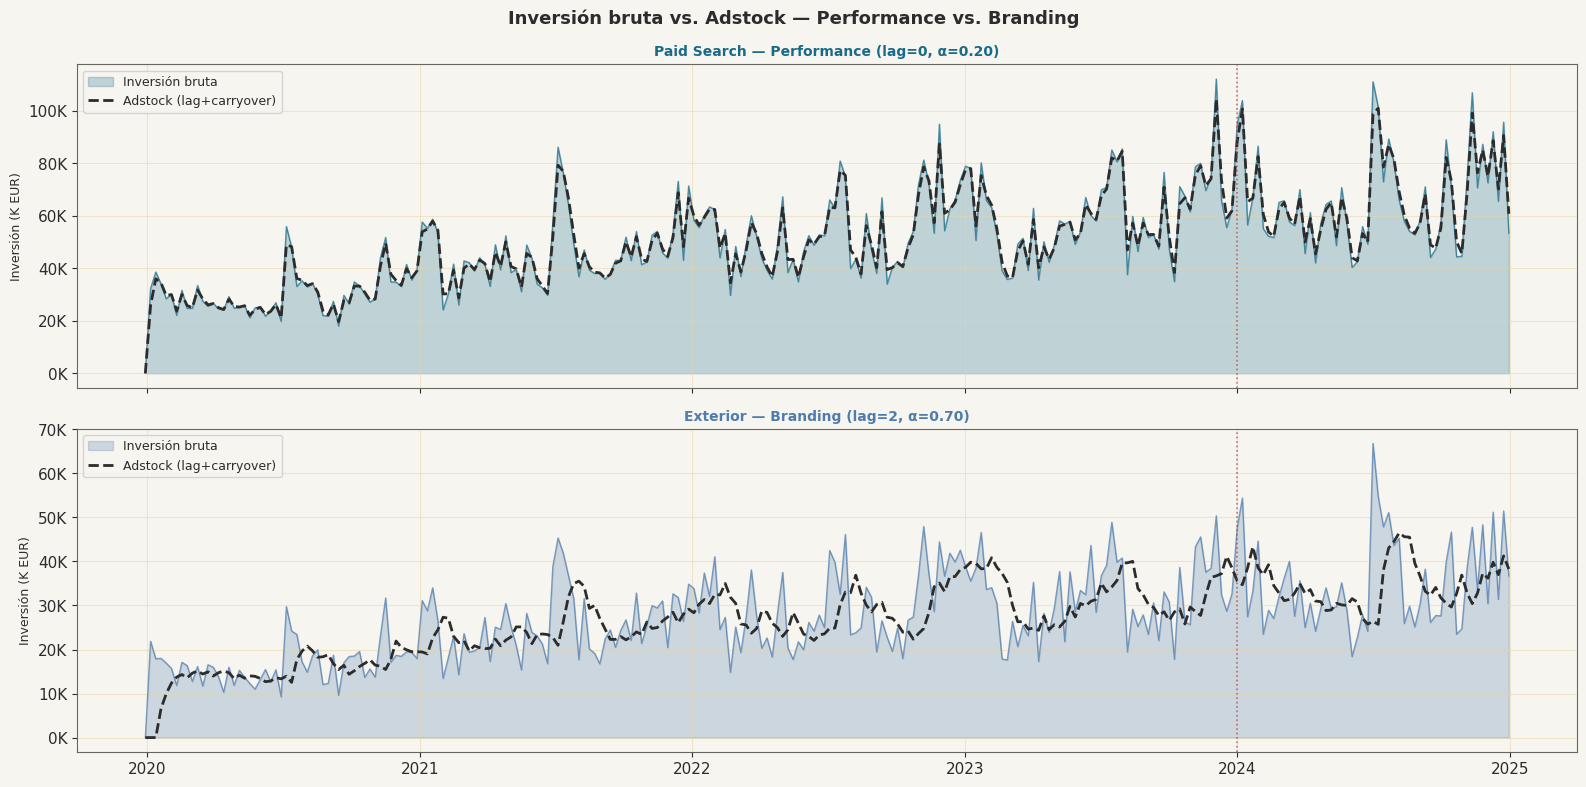

In [7]:
# Mostrar contraste bruto vs adstock para un canal performance (Paid Search) y uno branding (Exterior)
ejemplos = [
    ('Paid Search', 'adstock_paid_search', 'Performance (lag=0, α=0.20)'),
    ('Exterior',    'adstock_exterior',    'Branding (lag=2, α=0.70)'),
]

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fig.suptitle('Inversión bruta vs. Adstock — Performance vs. Branding',
             fontsize=13, fontweight='bold', color=KM['charcoal'])

for ax, (canal, ads_col, titulo) in zip(axes, ejemplos):
    color = CANAL_COLOR[canal]
    x = df_adstock['semana_inicio']
    bruto = df_inv[canal] / 1e3
    adst  = df_adstock[ads_col] / 1e3

    ax.fill_between(x, bruto, alpha=0.25, color=color, label='Inversión bruta')
    ax.plot(x, bruto, color=color, lw=1, alpha=0.7)
    ax.plot(x, adst, color=KM['charcoal'], lw=2, ls='--', label='Adstock (lag+carryover)')
    ax.axvline(pd.Timestamp('2024-01-01'), color=KM['negative'], lw=1.2, ls=':', alpha=0.7)
    ax.set_ylabel('Inversión (K EUR)', fontsize=9)
    ax.set_title(f'{canal} — {titulo}', fontsize=10, color=color, fontweight='bold')
    ax.legend(fontsize=9, loc='upper left')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.0f}K'))

plt.tight_layout()
save_fig('03b_bruto_vs_adstock')
plt.show()

## 7. Análisis de sensibilidad — Alpha ±0.1

Para cada canal, variamos alpha en \{alpha-0.2, alpha-0.1, alpha_base, alpha+0.1, alpha+0.2\} y medimos la correlación de Pearson entre el adstock resultante y Y_t. Si la correlación cambia poco, el modelo es robusto a la elección de alpha.

  Guardado: img\03c_sensibilidad_alpha.png


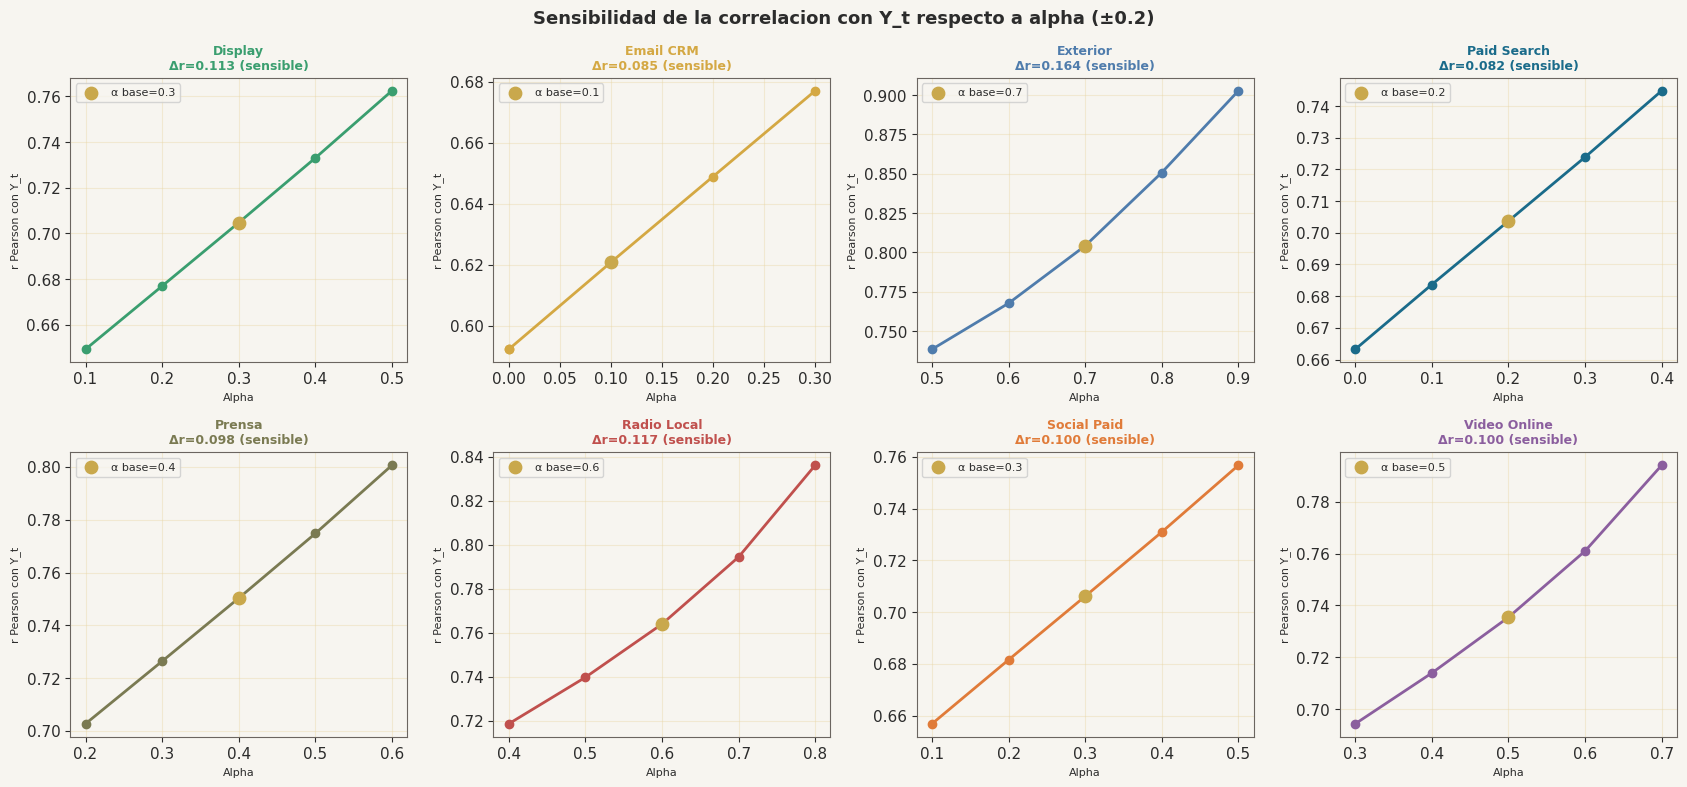

RESUMEN SENSIBILIDAD:
Canal            Alpha base   r_min   r_max  Delta r  Veredicto
-----------------------------------------------------------------
Display                0.30   0.649   0.762    0.113  SENSIBLE
Email CRM              0.10   0.592   0.677    0.085  SENSIBLE
Exterior               0.70   0.738   0.903    0.164  SENSIBLE
Paid Search            0.20   0.663   0.745    0.082  SENSIBLE
Prensa                 0.40   0.703   0.801    0.098  SENSIBLE
Radio Local            0.60   0.719   0.836    0.117  SENSIBLE
Social Paid            0.30   0.657   0.757    0.100  SENSIBLE
Video Online           0.50   0.694   0.794    0.100  SENSIBLE


In [8]:
y_t = df_v.set_index('semana_inicio')['venta_neta_sin_iva_eur']
# Alinear índice
y_t = y_t.reindex(df_adstock['semana_inicio'].values)
y_vals = y_t.values

sensibilidad = {}
for canal in CANALES:
    p = PARAMS[canal]
    alpha_base = p['alpha']
    alphas = np.clip([alpha_base - 0.2, alpha_base - 0.1, alpha_base,
                      alpha_base + 0.1, alpha_base + 0.2], 0.0, 0.95)
    corrs = []
    for a in alphas:
        ads = lag_adstock(df_inv[canal], lag=p['lag'], alpha=a).values
        # Máscara para NaN producidos por lag
        mask = ~(np.isnan(ads) | np.isnan(y_vals))
        r, _ = stats.pearsonr(ads[mask], y_vals[mask])
        corrs.append(r)
    sensibilidad[canal] = {'alphas': alphas, 'corrs': corrs, 'alpha_base': alpha_base}

fig, axes = plt.subplots(2, 4, figsize=(17, 8))
fig.suptitle('Sensibilidad de la correlacion con Y_t respecto a alpha (±0.2)',
             fontsize=13, fontweight='bold', color=KM['charcoal'])

for ax, canal in zip(axes.flatten(), CANALES):
    s = sensibilidad[canal]
    color = CANAL_COLOR.get(canal, KM['warm_gray'])
    ax.plot(s['alphas'], s['corrs'], color=color, lw=2, marker='o', ms=6)
    # Marcar el alpha base
    idx_base = list(s['alphas']).index(s['alpha_base']) if s['alpha_base'] in s['alphas'] else 2
    ax.scatter([s['alpha_base']], [s['corrs'][2]], color=KM['gold'], s=80, zorder=5,
               label=f'α base={s["alpha_base"]}')
    # Rango de variacion de la correlacion
    delta_r = max(s['corrs']) - min(s['corrs'])
    ax.set_title(f'{canal}\nΔr={delta_r:.3f} ({"robusto" if delta_r < 0.03 else "sensible"})',
                 fontsize=9, color=color, fontweight='bold')
    ax.set_xlabel('Alpha', fontsize=8)
    ax.set_ylabel('r Pearson con Y_t', fontsize=8)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.4)

plt.tight_layout()
save_fig('03c_sensibilidad_alpha')
plt.show()

print('RESUMEN SENSIBILIDAD:')
print(f'{"Canal":15s}  {"Alpha base":>10s}  {"r_min":>6s}  {"r_max":>6s}  {"Delta r":>7s}  {"Veredicto"}')
print('-' * 65)
for canal in CANALES:
    s = sensibilidad[canal]
    delta = max(s['corrs']) - min(s['corrs'])
    veredicto = 'ROBUSTO' if delta < 0.03 else ('moderado' if delta < 0.07 else 'SENSIBLE')
    print(f'{canal:15s}  {s["alpha_base"]:>10.2f}  {min(s["corrs"]):>6.3f}  '
          f'{max(s["corrs"]):>6.3f}  {delta:>7.3f}  {veredicto}')

## 8. Variables exógenas del calendario

Variables que capturan efectos estructurales no atribuibles a la inversión publicitaria.

In [9]:
# Selección de variables exógenas (basada en insights de Fase 2)
FLAGS_EXOG = [
    'black_friday_flag',
    'navidad_flag',
    'rebajas_flag',
    'semana_santa_flag',
    'incidencia_ecommerce_flag',
]
CONT_EXOG = [
    'temperatura_media_c',
    'turismo_indice',
]

df_exog = df_v[['semana_inicio'] + FLAGS_EXOG + CONT_EXOG].copy()

# Normalización z-score de variables continuas (para que los coeficientes sean comparables)
for col in CONT_EXOG:
    mu, sigma = df_exog[col].mean(), df_exog[col].std()
    df_exog[f'{col}_z'] = (df_exog[col] - mu) / sigma
    print(f'{col}: media={mu:.2f}, std={sigma:.2f} → normalizada a z-score')

CONT_EXOG_Z = [f'{c}_z' for c in CONT_EXOG]

# Estadísticas de las flags
print()
print('Semanas activas por flag exógena:')
for col in FLAGS_EXOG:
    n = df_exog[col].sum()
    print(f'  {col:30s}: {n:3.0f} semanas activas ({n/len(df_exog)*100:.1f}%)')

temperatura_media_c: media=17.18, std=6.09 → normalizada a z-score
turismo_indice: media=39.37, std=19.18 → normalizada a z-score

Semanas activas por flag exógena:
  black_friday_flag             :  13 semanas activas (5.0%)
  navidad_flag                  :  21 semanas activas (8.0%)
  rebajas_flag                  :  67 semanas activas (25.6%)
  semana_santa_flag             :  10 semanas activas (3.8%)
  incidencia_ecommerce_flag     :  67 semanas activas (25.6%)


## 9. Construcción de df_model — JOIN final

In [10]:
# 1. Base: ventas semanales + variables exógenas
df_model = df_v[['semana_inicio', 'anio', 'semana_iso',
                  'venta_neta_sin_iva_eur']].copy()

# 2. Añadir exógenas (flags + continuas normalizadas)
df_model = df_model.merge(
    df_exog[['semana_inicio'] + FLAGS_EXOG + CONT_EXOG_Z],
    on='semana_inicio', how='left'
)

# 3. Añadir adstock de cada canal
df_model = df_model.merge(
    df_adstock[['semana_inicio'] + ADSTOCK_COLS],
    on='semana_inicio', how='left'
)

# 4. Eliminar filas con NaN en canales (producidos por el lag máximo = 2 semanas)
n_antes = len(df_model)
df_model = df_model.dropna(subset=ADSTOCK_COLS).reset_index(drop=True)
n_despues = len(df_model)
print(f'Filas eliminadas por lag (NaN iniciales): {n_antes - n_despues}')
print(f'Semanas en df_model: {n_despues}')
print(f'Rango: {df_model.semana_inicio.min().date()} → {df_model.semana_inicio.max().date()}')
print(f'Shape: {df_model.shape}')
print(f'Columnas: {list(df_model.columns)}')

Filas eliminadas por lag (NaN iniciales): 0
Semanas en df_model: 262
Rango: 2019-12-30 → 2024-12-30
Shape: (262, 19)
Columnas: ['semana_inicio', 'anio', 'semana_iso', 'venta_neta_sin_iva_eur', 'black_friday_flag', 'navidad_flag', 'rebajas_flag', 'semana_santa_flag', 'incidencia_ecommerce_flag', 'temperatura_media_c_z', 'turismo_indice_z', 'adstock_display', 'adstock_email_crm', 'adstock_exterior', 'adstock_paid_search', 'adstock_prensa', 'adstock_radio_local', 'adstock_social_paid', 'adstock_video_online']


In [11]:
# Split train / test explícito
TRAIN_END = pd.Timestamp('2023-12-31')
TEST_START = pd.Timestamp('2024-01-01')

df_train = df_model[df_model['semana_inicio'] <= TRAIN_END].copy()
df_test  = df_model[df_model['semana_inicio'] >= TEST_START].copy()

print(f'TRAIN: {len(df_train)} semanas  ({df_train.semana_inicio.min().date()} → {df_train.semana_inicio.max().date()})')
print(f'TEST:  {len(df_test)} semanas  ({df_test.semana_inicio.min().date()} → {df_test.semana_inicio.max().date()})')
print(f'Proporción test: {len(df_test)/len(df_model)*100:.1f}%')

# Verificación de no solapamiento
overlap = set(df_train['semana_inicio']) & set(df_test['semana_inicio'])
assert len(overlap) == 0, f'ERROR: solapamiento en semanas {overlap}'
print('Verificacion: sin solapamiento train/test.')

TRAIN: 209 semanas  (2019-12-30 → 2023-12-25)
TEST:  53 semanas  (2024-01-01 → 2024-12-30)
Proporción test: 20.2%
Verificacion: sin solapamiento train/test.


## 10. Diagnóstico de la matriz de features

Análisis de correlaciones, distribución y estabilidad de las features antes de modelar.

  Guardado: img\03d_correlacion_features.png


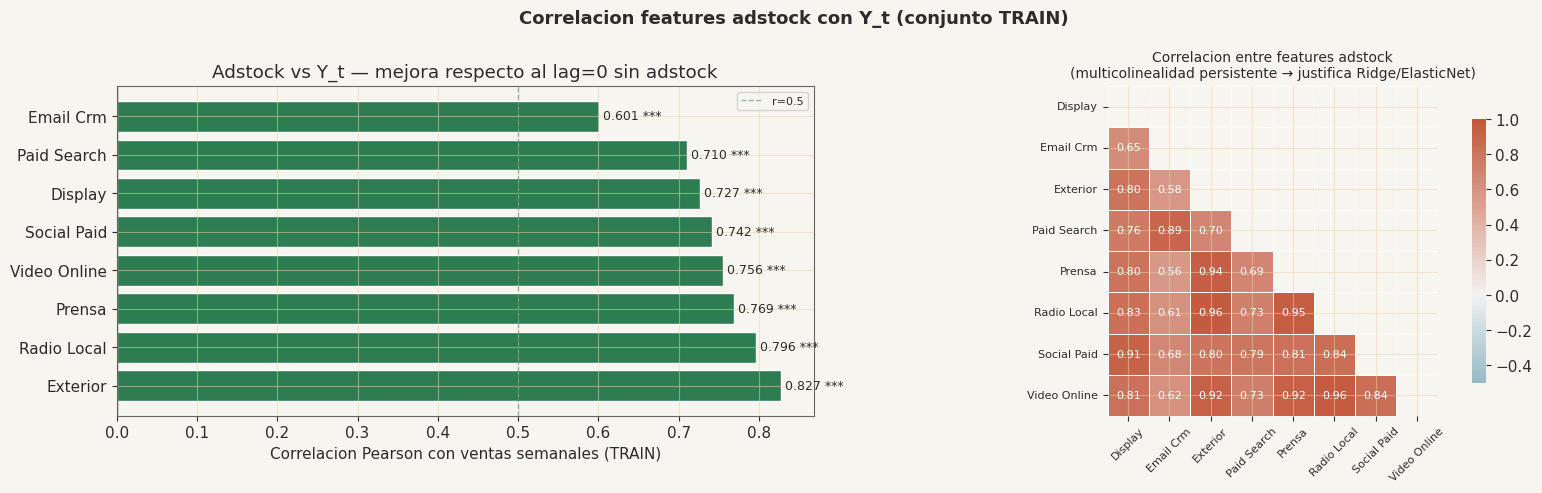

In [12]:
# Correlación de cada adstock con Y_t (train únicamente)
y_train = df_train['venta_neta_sin_iva_eur']

corr_adstock = {}
for col in ADSTOCK_COLS:
    r, pval = stats.pearsonr(df_train[col], y_train)
    canal = col.replace('adstock_', '').replace('_', ' ').title()
    corr_adstock[canal] = {'r': r, 'pval': pval}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Correlacion features adstock con Y_t (conjunto TRAIN)',
             fontsize=13, fontweight='bold', color=KM['charcoal'])

# Barras de correlacion
ax = axes[0]
canales_sorted = sorted(corr_adstock.keys(), key=lambda c: corr_adstock[c]['r'], reverse=True)
rs = [corr_adstock[c]['r'] for c in canales_sorted]
colors_bar = [KM['positive'] if r > 0.5 else (KM['neutral'] if r > 0.3 else KM['negative']) for r in rs]
bars = ax.barh(canales_sorted, rs, color=colors_bar, edgecolor='white')
ax.axvline(0, color=KM['charcoal'], lw=1)
ax.axvline(0.5, color=KM['positive'], lw=1, ls='--', alpha=0.5, label='r=0.5')
for bar, r, c in zip(bars, rs, canales_sorted):
    sig = '***' if corr_adstock[c]['pval'] < 0.001 else ('**' if corr_adstock[c]['pval'] < 0.01 else '*')
    ax.text(r + 0.005, bar.get_y() + bar.get_height()/2,
            f'{r:.3f} {sig}', va='center', fontsize=9)
ax.set_xlabel('Correlacion Pearson con ventas semanales (TRAIN)')
ax.set_title('Adstock vs Y_t — mejora respecto al lag=0 sin adstock')
ax.legend(fontsize=8)

# Heatmap de correlacion entre adstock features
ax2 = axes[1]
corr_matrix = df_train[ADSTOCK_COLS].corr()
labels = [c.replace('adstock_','').replace('_',' ').title() for c in ADSTOCK_COLS]
corr_matrix.index = labels
corr_matrix.columns = labels
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(corr_matrix, ax=ax2, mask=mask, cmap=cmap, center=0,
            annot=True, fmt='.2f', linewidths=0.5, linecolor='white',
            vmin=-0.5, vmax=1, square=True, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 8})
ax2.set_title('Correlacion entre features adstock\n(multicolinealidad persistente → justifica Ridge/ElasticNet)',
              fontsize=10)
ax2.tick_params(axis='x', rotation=45, labelsize=8)
ax2.tick_params(axis='y', rotation=0, labelsize=8)

plt.tight_layout()
save_fig('03d_correlacion_features')
plt.show()

In [13]:
# Variance Inflation Factor (VIF) — cuantifica la multicolinealidad
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    from statsmodels.tools.tools import add_constant
    HAS_VIF = True
except ImportError:
    HAS_VIF = False
    print('statsmodels no disponible para VIF. Instalar con: pip install statsmodels')

if HAS_VIF:
    X_vif = add_constant(df_train[ADSTOCK_COLS].fillna(0))
    vif_data = pd.DataFrame()
    vif_data['Feature'] = ADSTOCK_COLS
    vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i+1)
                       for i in range(len(ADSTOCK_COLS))]
    vif_data['Canal'] = [c.replace('adstock_','').replace('_',' ').title() for c in ADSTOCK_COLS]
    vif_data = vif_data.sort_values('VIF', ascending=False)

    print('VIF POR CANAL (TRAIN):')
    print(f'{"Canal":20s}  {"VIF":>8s}  {"Interpretacion"}')
    print('-' * 55)
    for _, row in vif_data.iterrows():
        interp = 'SEVERO' if row['VIF'] > 10 else ('moderado' if row['VIF'] > 5 else 'bajo')
        print(f'{row["Canal"]:20s}  {row["VIF"]:>8.1f}  {interp}')
    print()
    print('VIF alto confirma multicolinealidad. Ridge/ElasticNet es la solución correcta.')
    print('OLS con VIF > 10 produciría coeficientes inestables e invertidos.')

VIF POR CANAL (TRAIN):
Canal                      VIF  Interpretacion
-------------------------------------------------------
Radio Local               27.3  SEVERO
Exterior                  15.5  SEVERO
Video Online              13.7  SEVERO
Prensa                    11.4  SEVERO
Social Paid                8.2  moderado
Paid Search                7.5  moderado
Display                    6.8  moderado
Email Crm                  5.0  moderado

VIF alto confirma multicolinealidad. Ridge/ElasticNet es la solución correcta.
OLS con VIF > 10 produciría coeficientes inestables e invertidos.


## 11. Exportación de df_model.parquet

In [14]:
path_model = DATA_OUT / 'df_model.parquet'
df_model.to_parquet(path_model, index=False)
print(f'df_model.parquet exportado: {df_model.shape} — {path_model.stat().st_size/1024:.1f} KB')
print()
print('RESUMEN FINAL DEL ARTEFACTO:')
print(f'  Semanas totales:  {len(df_model)}')
print(f'  Semanas TRAIN:    {len(df_train)}  (2020-2023)')
print(f'  Semanas TEST:     {len(df_test)}  (2024)')
print(f'  Features adstock: {len(ADSTOCK_COLS)}')
print(f'  Features exog:    {len(FLAGS_EXOG) + len(CONT_EXOG_Z)}')
print(f'  Total features X: {len(ADSTOCK_COLS) + len(FLAGS_EXOG) + len(CONT_EXOG_Z)}')
print()
print('Columnas del modelo:')
for col in df_model.columns:
    tipo = 'TARGET' if col == 'venta_neta_sin_iva_eur' else \
           ('ADSTOCK' if col.startswith('adstock_') else \
           ('FLAG' if col.endswith('_flag') else \
           ('CONT' if col.endswith('_z') else 'META')))
    print(f'  {tipo:8s}  {col}')

df_model.parquet exportado: (262, 19) — 40.4 KB

RESUMEN FINAL DEL ARTEFACTO:
  Semanas totales:  262
  Semanas TRAIN:    209  (2020-2023)
  Semanas TEST:     53  (2024)
  Features adstock: 8
  Features exog:    7
  Total features X: 15

Columnas del modelo:
  META      semana_inicio
  META      anio
  META      semana_iso
  TARGET    venta_neta_sin_iva_eur
  FLAG      black_friday_flag
  FLAG      navidad_flag
  FLAG      rebajas_flag
  FLAG      semana_santa_flag
  FLAG      incidencia_ecommerce_flag
  CONT      temperatura_media_c_z
  CONT      turismo_indice_z
  ADSTOCK   adstock_display
  ADSTOCK   adstock_email_crm
  ADSTOCK   adstock_exterior
  ADSTOCK   adstock_paid_search
  ADSTOCK   adstock_prensa
  ADSTOCK   adstock_radio_local
  ADSTOCK   adstock_social_paid
  ADSTOCK   adstock_video_online


## 12. Resumen de decisiones para la Fase 4

| Decisión | Valor | Justificación |
|---|---|---|
| **Features X** | 8 adstock + 5 flags + 2 continuas = 15 | Parsimonia + cobertura de efectos clave |
| **Normalización** | Solo variables continuas (z-score) | Flags ya son 0/1; adstock en EUR → Ridge los escala internamente |
| **Semanas eliminadas por lag** | Máx 2 (lag máximo aplicado) | Pérdida mínima; cubre todo 2020-2024 |
| **Multicolinealidad** | VIF alto en todos los canales | Confirmado → Ridge/ElasticNet obligatorio; OLS sesgado |
| **Restricción betas ≥ 0** | No forzada en Fase 4 | Si canal sale negativo → documentar como limitación, no suprimir artificialmente |

**Siguiente fase:** `04_modelos_clasicos.ipynb` — Ridge, Lasso y ElasticNet con TimeSeriesSplit. Análisis de distribución 2024 vs train (KS test). Interpretación de coeficientes y ROAS por canal.